# Experimenting DiffRec on Different datasets

This notebook is used for inspecting the based DiffRec implementation on mentioned datasets.

The metrics used for evaluation are __Recall@N__ and __Normalized Discounted Cumulative Gain (NDCG)@N__, with N = {20}.

Before using this notebook, please ensure all necessary packages are installed. The list of packages can be found inside the `requirements.txt`.

In [1]:
import os
from argparse import Namespace

In [2]:
os.environ["TQDM_DISABLE"] = "1"

In [3]:
from inference import infer_model

# 1. Inference

In [30]:
topN = "[20]"
metrics_name = ["Recall@", "NDCG@"]

metrics_cols = [f'{name}{n}' for n in eval(topN) for name in metrics_name]

dataset_name = ["gowalla", "movielens", "yelp", "amazon-books", "steam"]
dataset_labels = ["Gowalla", "Movielens 1M", "Yelp", "Amazon Books", "Steam"]

params = "_lr0.0001_wd1e-05_bs512_ibs512_dims[1000, 1000]_emb12_x0_steps60_scale0.1_min1e-05_max0.02_sample0_reweightTrue_"

attempts = ["r1", "r2", "r3"]

In [5]:
def extract_test_metrics(results):
    N_value = eval(topN)
    
    metrics = dict()

    test_results = results[1]

    for i, n in enumerate(N_value):
        for j, name in enumerate(metrics_name):
            metrics[f'{name}{n}'] = test_results[1+j][i]

    return metrics

In [6]:
data_results = dict()

for ds_name in dataset_name:
    data_results[ds_name] = dict()

    N_value = eval(topN)
    # Perform inference and retrieve results
    for attempt in attempts:

        # Arguments for inference
        args = Namespace(
            cuda = True,
            dataset = ds_name,
            model_path = "./saved_models/",
            model_name = ds_name + params + attempt + ".pth",
            tst_w_val = True,
            batch_size = 512,
            topN = topN,
            steps = 60,
            noise_scale = 0.1, 
            noise_min = 1e-5,
            noise_max = 0.02,
            sampling_steps=0
        )

        # Run inference function
        infer_result = infer_model(args)

        # Retrieve results
        extracted_results = extract_test_metrics(infer_result)
        for i, n in enumerate(N_value):
            for j, name in enumerate(metrics_name):
                if data_results[ds_name].get(f'{name}{n}s') is None:
                    data_results[ds_name][f'{name}{n}s'] = []
               
                data_results[ds_name][f'{name}{n}s'].append(extracted_results[f'{name}{n}'])

args: Namespace(dataset='gowalla', data_path='./datasets/', batch_size=512, topN='[20]', tst_w_val=True, cuda=True, gpu='0', log_name='log', mean_type='x0', steps=60, noise_schedule='linear-var', noise_scale=0.1, noise_min=1e-05, noise_max=0.02, sampling_noise=False, sampling_steps=0, model_path='./saved_models/', model_name='gowalla_lr0.0001_wd1e-05_bs512_ibs512_dims[1000, 1000]_emb12_x0_steps60_scale0.1_min1e-05_max0.02_sample0_reweightTrue_r1.pth')
Starting time:  2026-04-19 15:15:00
user num: 29858
item num: 40988
data ready.
models ready.
[Valid]: Precision: 0.0387 Recall: 0.1408 NDCG: 0.1088 MRR: 0.184
[Test]: Precision: 0.0258 Recall: 0.147 NDCG: 0.1015 MRR: 0.1483
args: Namespace(dataset='gowalla', data_path='./datasets/', batch_size=512, topN='[20]', tst_w_val=True, cuda=True, gpu='0', log_name='log', mean_type='x0', steps=60, noise_schedule='linear-var', noise_scale=0.1, noise_min=1e-05, noise_max=0.02, sampling_noise=False, sampling_steps=0, model_path='./saved_models/', mod

In [7]:
data_results

{'gowalla': {'Recall@20s': [0.147, 0.147, 0.147],
  'NDCG@20s': [0.1015, 0.1015, 0.1015]},
 'movielens': {'Recall@20s': [0.1297, 0.1297, 0.1297],
  'NDCG@20s': [0.0877, 0.0877, 0.0877]},
 'yelp': {'Recall@20s': [0.0621, 0.0621, 0.0609],
  'NDCG@20s': [0.0342, 0.0342, 0.033]},
 'amazon-books': {'Recall@20s': [0.0655, 0.0655, 0.0655],
  'NDCG@20s': [0.0345, 0.0345, 0.0345]},
 'steam': {'Recall@20s': [0.1531, 0.1531, 0.1531],
  'NDCG@20s': [0.0776, 0.0776, 0.0776]}}

# 2. Illustration

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(
    style="darkgrid",
    palette="deep",        # default seaborn colors (blue/orange)
    context="notebook"     # scaling similar to your figure
)

plt.rcParams.update({
    "figure.figsize": (6, 8),
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10
})

In [38]:
df = pd.DataFrame.from_dict(data_results, orient='index')

df.index.name = "Datasets"

# Averaging
for column in df.columns:
    df[column[:-1]] = df[column].apply(lambda col: np.mean(col))

df

,Recall@20s,NDCG@20s,Recall@20,NDCG@20
Datasets,,,,
gowalla,"[0.147, 0.147, 0.147]","[0.1015, 0.1015, 0.1015]",0.1470,0.1015
movielens,"[0.1297, 0.1297, 0.1297]","[0.0877, 0.0877, 0.0877]",0.1297,0.0877
yelp,"[0.0621, 0.0621, 0.0609]","[0.0342, 0.0342, 0.033]",0.0617,0.0338
amazon-books,"[0.0655, 0.0655, 0.0655]","[0.0345, 0.0345, 0.0345]",0.0655,0.0345
steam,"[0.1531, 0.1531, 0.1531]","[0.0776, 0.0776, 0.0776]",0.1531,0.0776


In [39]:
def plot_dataset(df: pd.DataFrame, xlabel_mapping: dict = None): 
    xlabels = xlabel_mapping if xlabel_mapping is not None else df.index
    models = df.index
    x = np.arange(len(models))

    N_values = eval(topN)
    width = 0.6 / len(N_values)
    fig, axs = plt.subplots(nrows=len(metrics_name), figsize=(6, 4 * len(metrics_name)))

    for i, metric_name in enumerate(metrics_name):
        for j, n in enumerate(N_values):
            offset = (j - (len(N_values) - 1) / 2) * width
            axs[i].bar(x + offset, df[f'{metric_name}{n}'], width, label=f'{metric_name}{n}')
        
        axs[i].set_xticks(x)
        axs[i].set_xticklabels([xlabels[model] for model in models], rotation=20)

        axs[i].set_ylabel(metric_name)
        axs[i].legend()

    
    plt.tight_layout()
    plt.show()

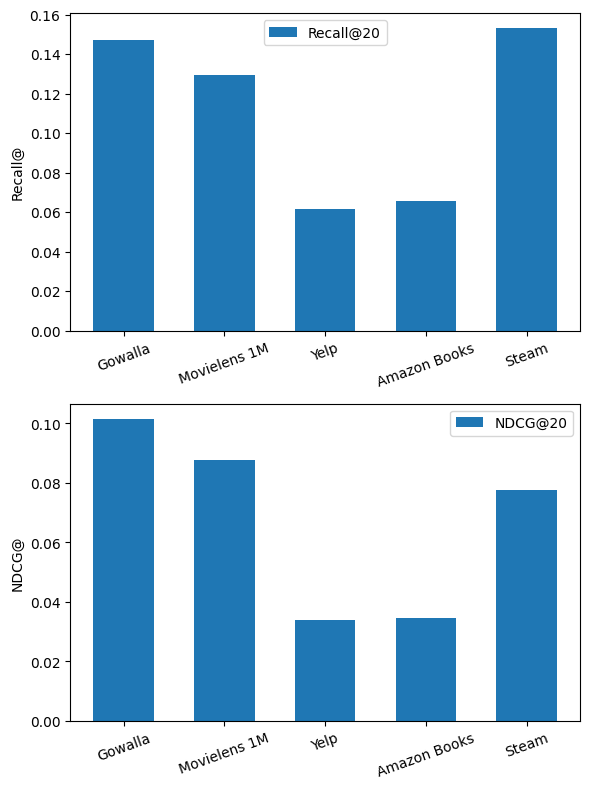

In [40]:
plot_dataset(df[metrics_cols], dict(zip(df.index, dataset_labels)))